<h3  style = "color: skyblue" >Importing Libraries<h3>

In [91]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, train_test_split

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


<h3  style = "color: skyblue" >Data Ingestion and Loading<h3>

In [92]:
df = pd.read_excel("../data/premiums_young_with_gr.xlsx")
print("Few observations:")
df.head()

Few observations:


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


<h3 style = "color:skyblue" >Data Overview</h3>

In [93]:
print("Number of rows and columns:", df.shape)
print("Number of duplicated observations:", df.duplicated().sum())
print("====" * 10)
print("Data Types of each fields:\n")
print(df.dtypes)
print("====" * 10)
print("Number of missing values per columns:")
df.isna().sum()

Number of rows and columns: (20096, 14)
Number of duplicated observations: 0
Data Types of each fields:

Age                       int64
Gender                   object
Region                   object
Marital_status           object
Number Of Dependants      int64
BMI_Category             object
Smoking_Status           object
Employment_Status        object
Income_Level             object
Income_Lakhs              int64
Medical History          object
Insurance_Plan           object
Annual_Premium_Amount     int64
Genetical_Risk            int64
dtype: object
Number of missing values per columns:


Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           2
Employment_Status        1
Income_Level             4
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
Genetical_Risk           0
dtype: int64

<h3 style = "color:skyblue" >Sanity Cleaning</h3>

In [94]:
#making field names consistent
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [95]:
#lower + snakecase
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [96]:
#since the number of missng value is small we can delete it
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

<h3 style = "color:skyblue" >Exploratory Data Analysis</h3>

#### 1. Summary Stats

In [97]:
print("Quick Summary Statistics:")
df.describe()

Quick Summary Statistics:


,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


Problems -
* certainly an outliers in the `age` field.
* number of dependants cannot be `negative`
* maybe an outlier in income_lakhs

In [98]:
# solve for the number of dependants
df['number_of_dependants'].unique()

array([ 0,  2,  1,  3, -3, -1], dtype=int64)

In [99]:
# there are 72 observations that is less that has negative values
# there may be some error in data entry and maybe it is +ve values
# talked to business and they said to replace with +ve values 
df[df['number_of_dependants'] < 0].shape

(22, 14)

In [100]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df['number_of_dependants'].unique()

array([0, 2, 1, 3], dtype=int64)

#### 2. Univariate Analysis - numeric 

In [101]:
numeric_columns = df.select_dtypes('number').columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

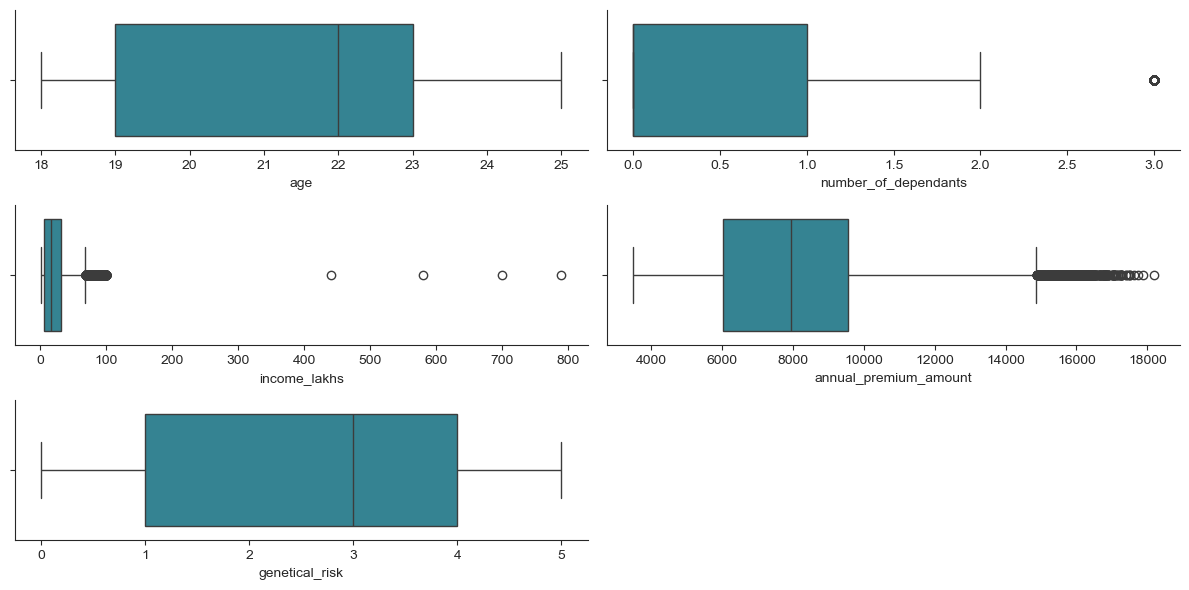

In [102]:
#solve for outliers
#numeric
plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df[col], color="#258DA2")
    
    
plt.tight_layout()
sns.despine()
plt.show()

In [103]:
# Outlier Treatment for age column 
# We do not need Statistical techniques for removing the outlier in age
# Simply use a threshold value

df[df['age'] > 100].head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk


In [104]:
df[df['age'] > 100]['age'].unique()

array([], dtype=int64)

In [105]:
#do reverse condition for filtering the age
#create a copy
data = df[df['age'] <= 100].copy()
data['age'].describe()

count    20090.000000
mean        21.494375
std          2.294052
min         18.000000
25%         19.000000
50%         22.000000
75%         23.000000
max         25.000000
Name: age, dtype: float64

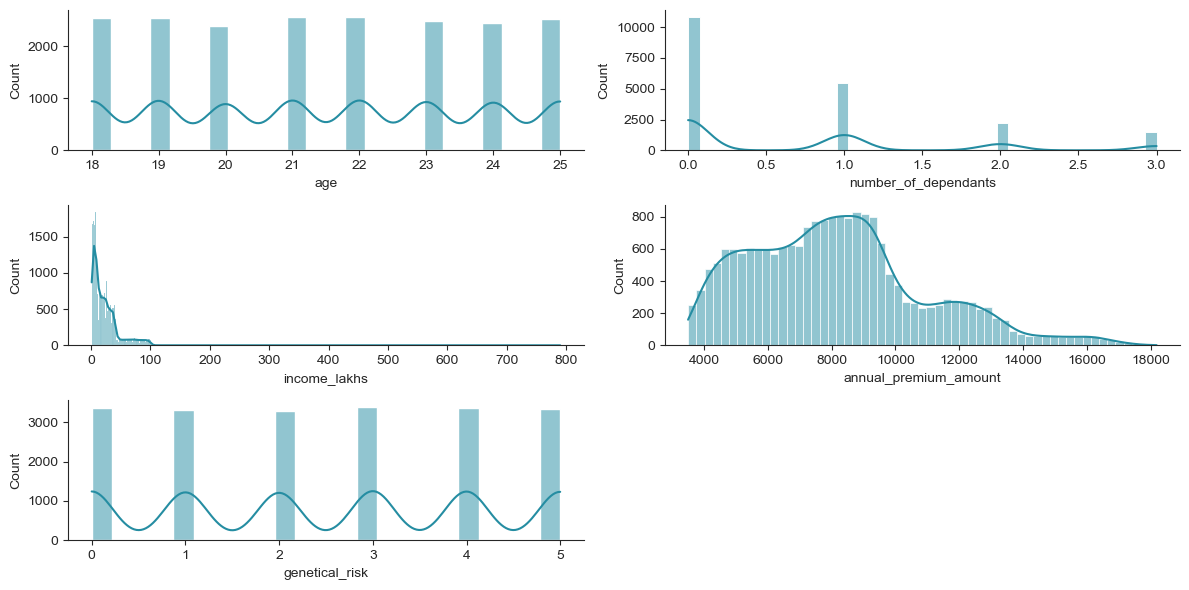

In [106]:
#distribution plot with outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()



In [107]:
# Outlier Treatment for income_lakhs column
# Using an IQR method to solve outlier problem

data['income_lakhs'].describe()


count    20090.000000
mean        22.510851
std         23.420493
min          1.000000
25%          6.000000
50%         16.000000
75%         31.000000
max        790.000000
Name: income_lakhs, dtype: float64

In [108]:
#quantile
Q1, Q3 = data['income_lakhs'].quantile([0.25, 0.75])
Q1, Q3

(6.0, 31.0)

In [109]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound


In [110]:
get_iqr_bounds(data['income_lakhs'])

(-31.5, 68.5)

- 67 LPA is okay but can I use it as my upperbound
- Try bunch of other methods

In [111]:
data['income_lakhs'].quantile(0.999)

100.0

In [112]:
qunatile_threshhold = data['income_lakhs'].quantile(0.999)
qunatile_threshhold

100.0

1 Cr income is okay when we use upper bound as 0.999

In [113]:
print("Observations that has income more than threshold i.e 1 Cr: ")
data[data['income_lakhs'] > qunatile_threshhold]


Observations that has income more than threshold i.e 1 Cr: 


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1677,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636,3
4311,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888,5
4661,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424,3
6251,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586,0


In [114]:
print(f"Number of such observations: {data[data['income_lakhs'] > qunatile_threshhold].shape}")

Number of such observations: (4, 14)


In [115]:
# drop those columns that has income > 1 Cr
# do reverse condition
data = data[data['income_lakhs'] <= qunatile_threshhold]
data["income_lakhs"].describe()

count    20086.000000
mean        22.390371
std         21.732062
min          1.000000
25%          6.000000
50%         16.000000
75%         31.000000
max        100.000000
Name: income_lakhs, dtype: float64

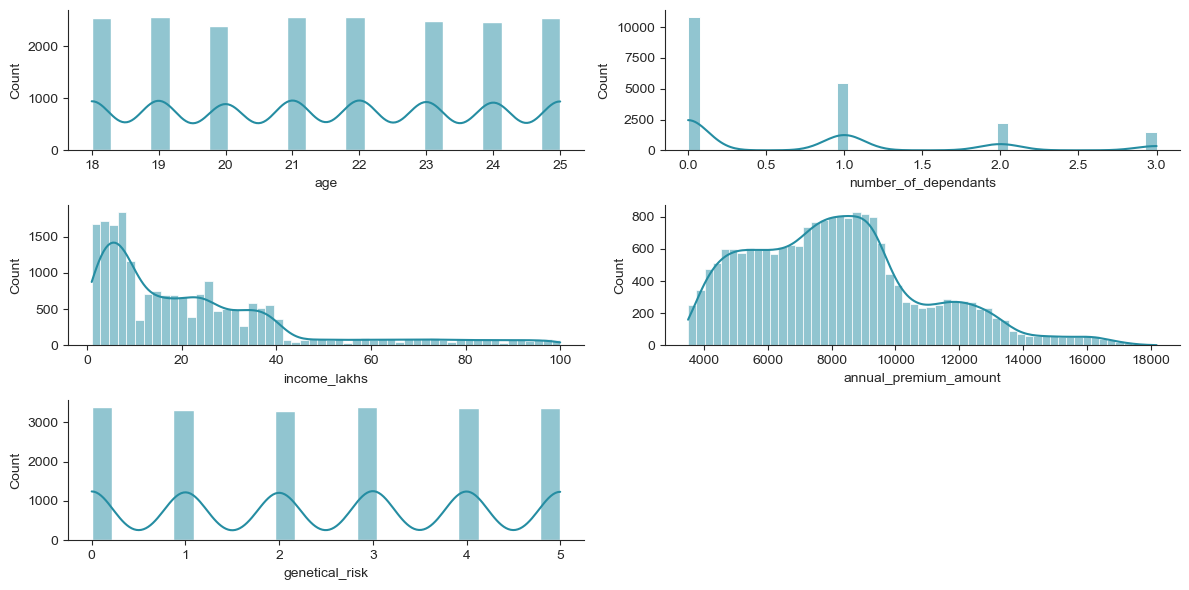

In [116]:
#distribution plot after removal of outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()

#### 2. Bivariate Analysis - numeric


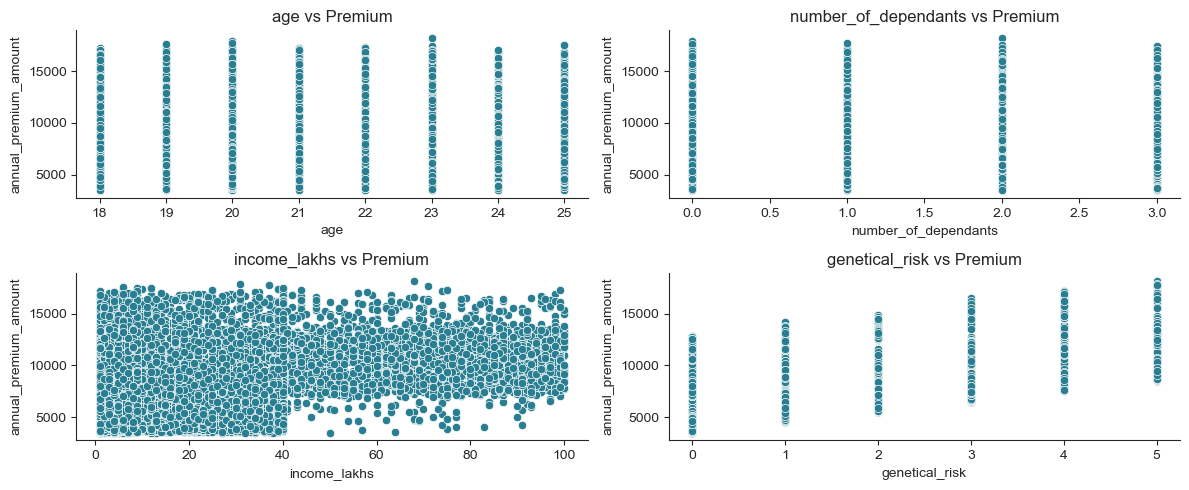

In [117]:

# Scatter plots: numeric vs target
scatter_cols = numeric_columns.drop('annual_premium_amount')

plt.figure(figsize=(12, 5))

ncols = 2
nrows = math.ceil(len(scatter_cols) / ncols)

for i, col in enumerate(scatter_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.scatterplot(data=data, x=col, y='annual_premium_amount', color="#297F91")
    plt.title(f"{col} vs Premium")

plt.tight_layout()
sns.despine()
plt.show()


#### Categorical Columns

In [118]:
categorical_cols = data.select_dtypes('object').columns
categorical_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [119]:
for col in categorical_cols:
    print(col, ":", data[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


There is clearly some data inconsistency in smoking status


In [120]:
#make value consistent
data['smoking_status'] = data['smoking_status'].replace({
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})

data['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

#### Summary Stats

In [121]:
data.select_dtypes('object').describe().T

,count,unique,top,freq
gender,20086,2,Male,11055
region,20086,4,Southeast,6969
marital_status,20086,2,Unmarried,18075
bmi_category,20086,4,Normal,11599
smoking_status,20086,3,No Smoking,13860
employment_status,20086,3,Freelancer,10043
income_level,20086,4,<10L,7721
medical_history,20086,9,No Disease,16873
insurance_plan,20086,3,Bronze,14177


####  Univariate Analysis - categorical

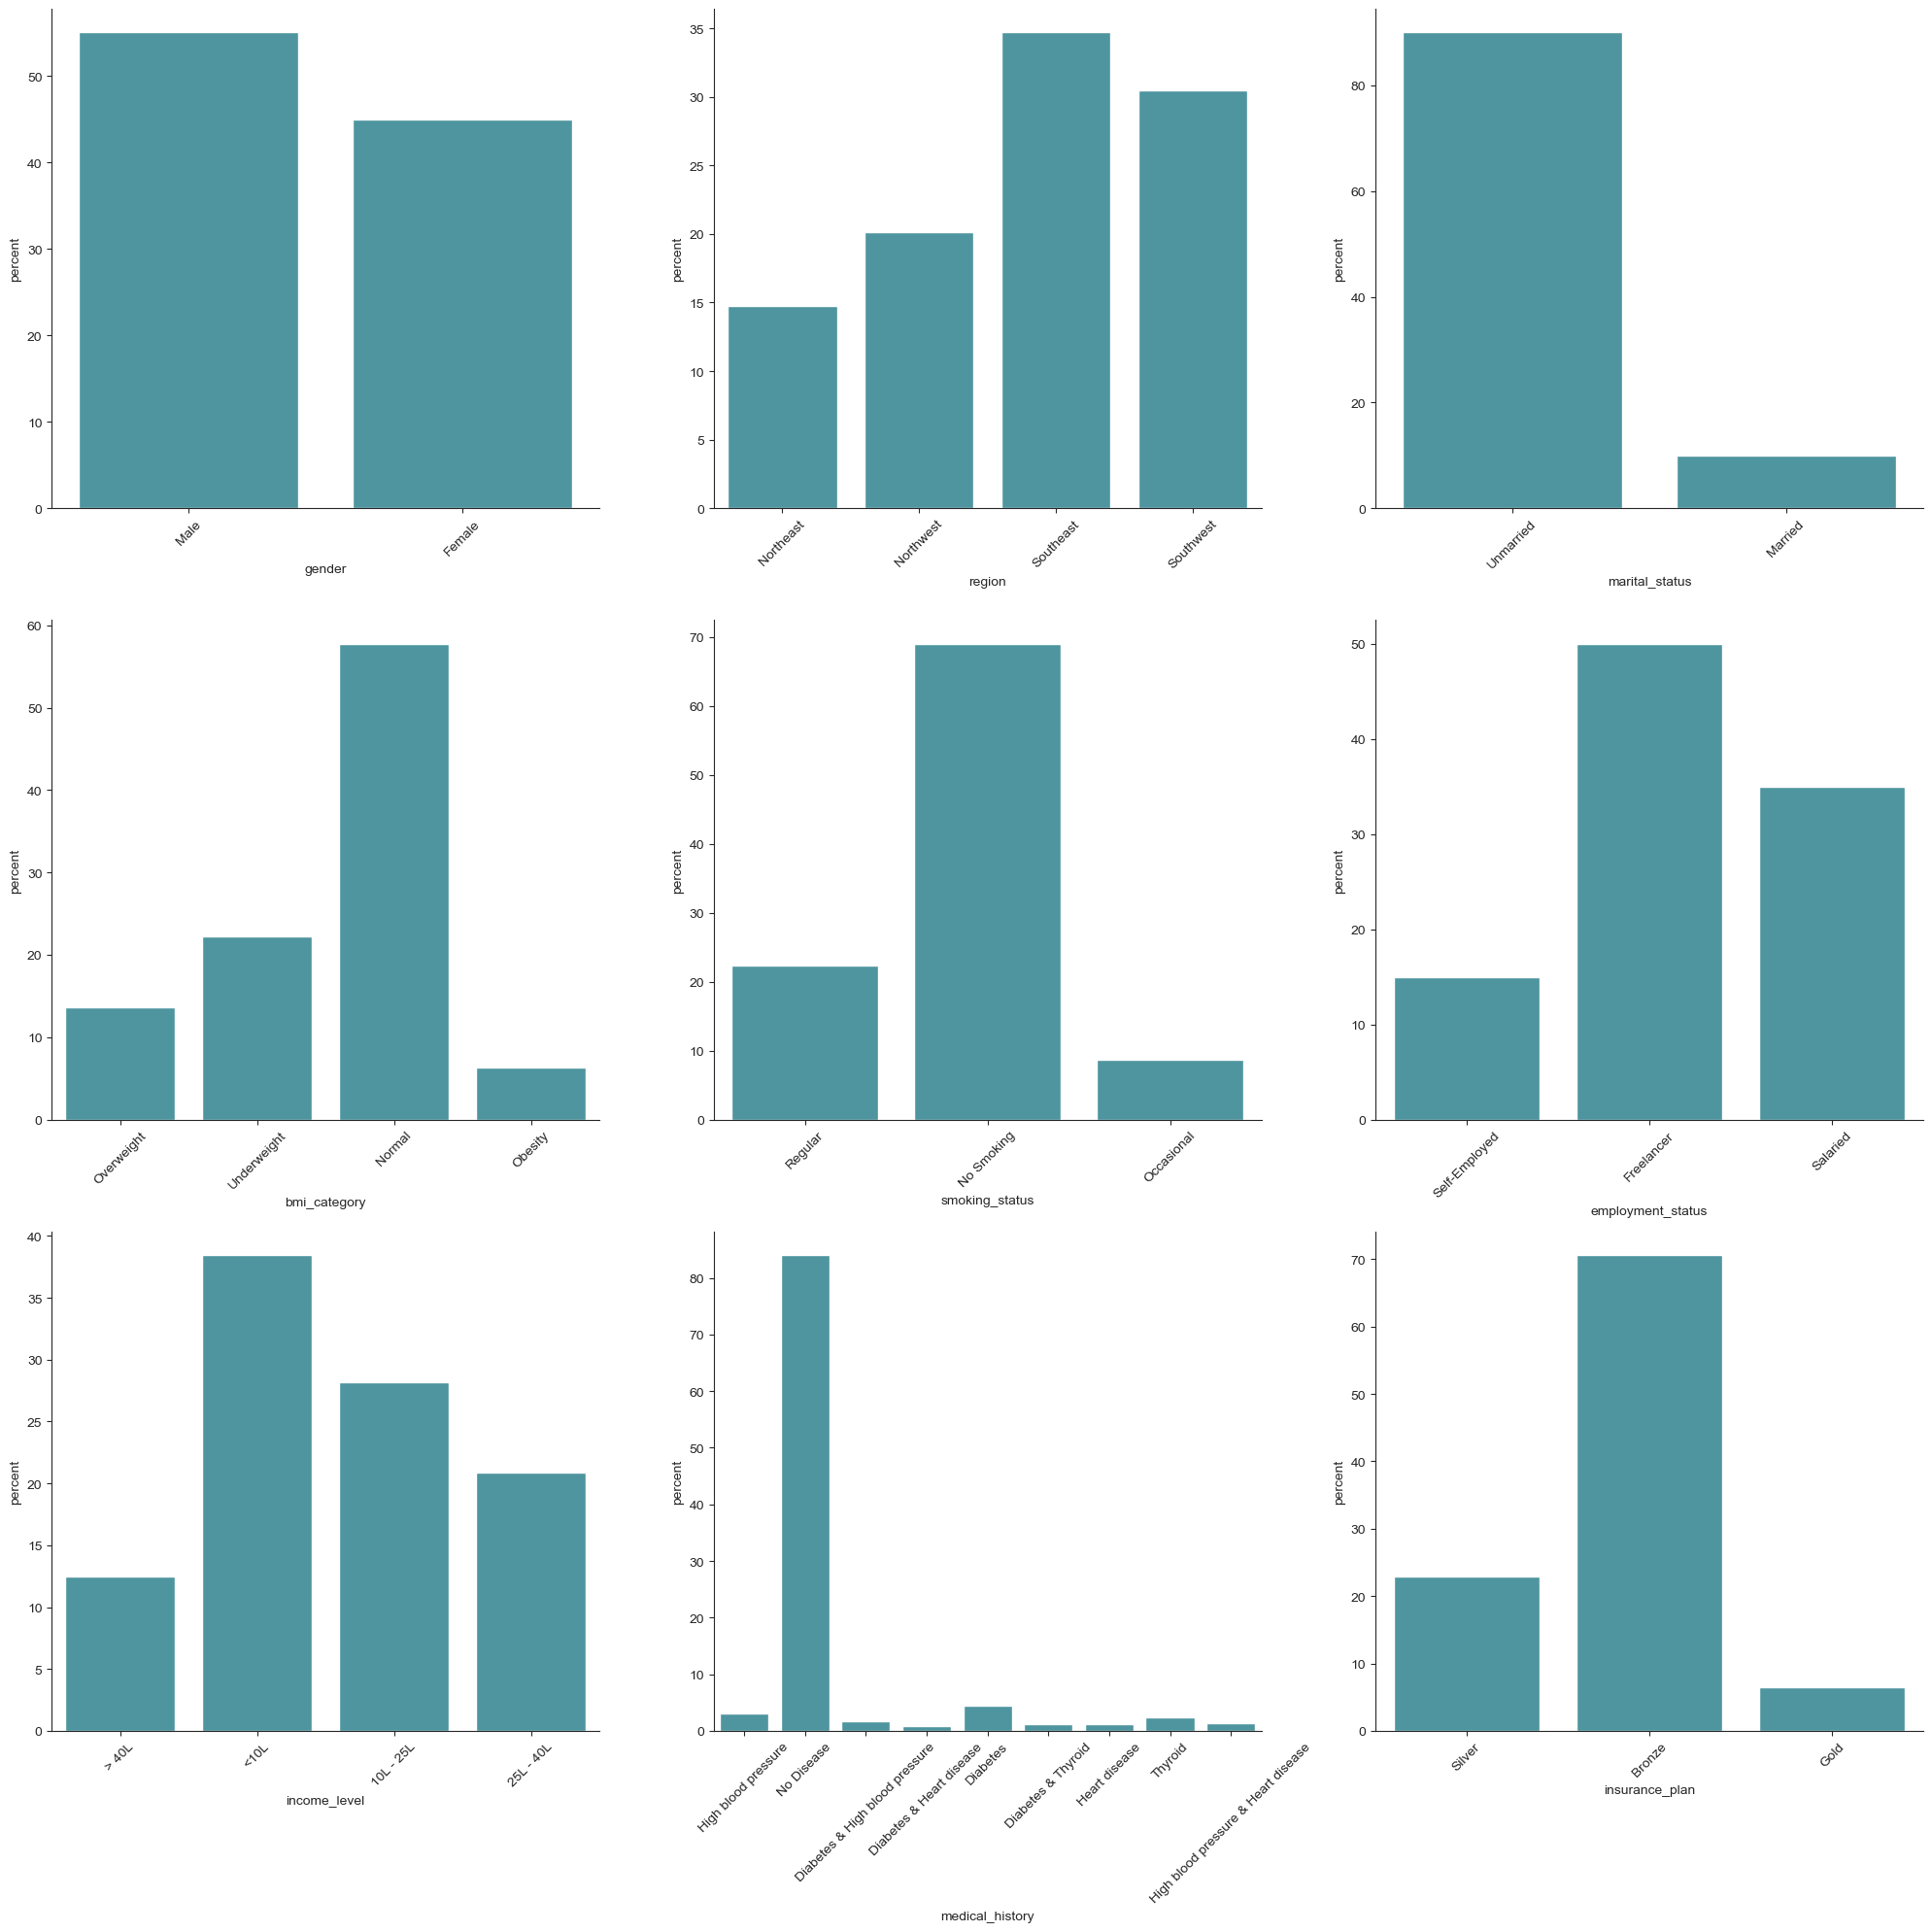

In [122]:
plt.figure(figsize=(20, 20))

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)

for i, col in enumerate(categorical_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent')
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


#### Bivariate Analysis - categorical


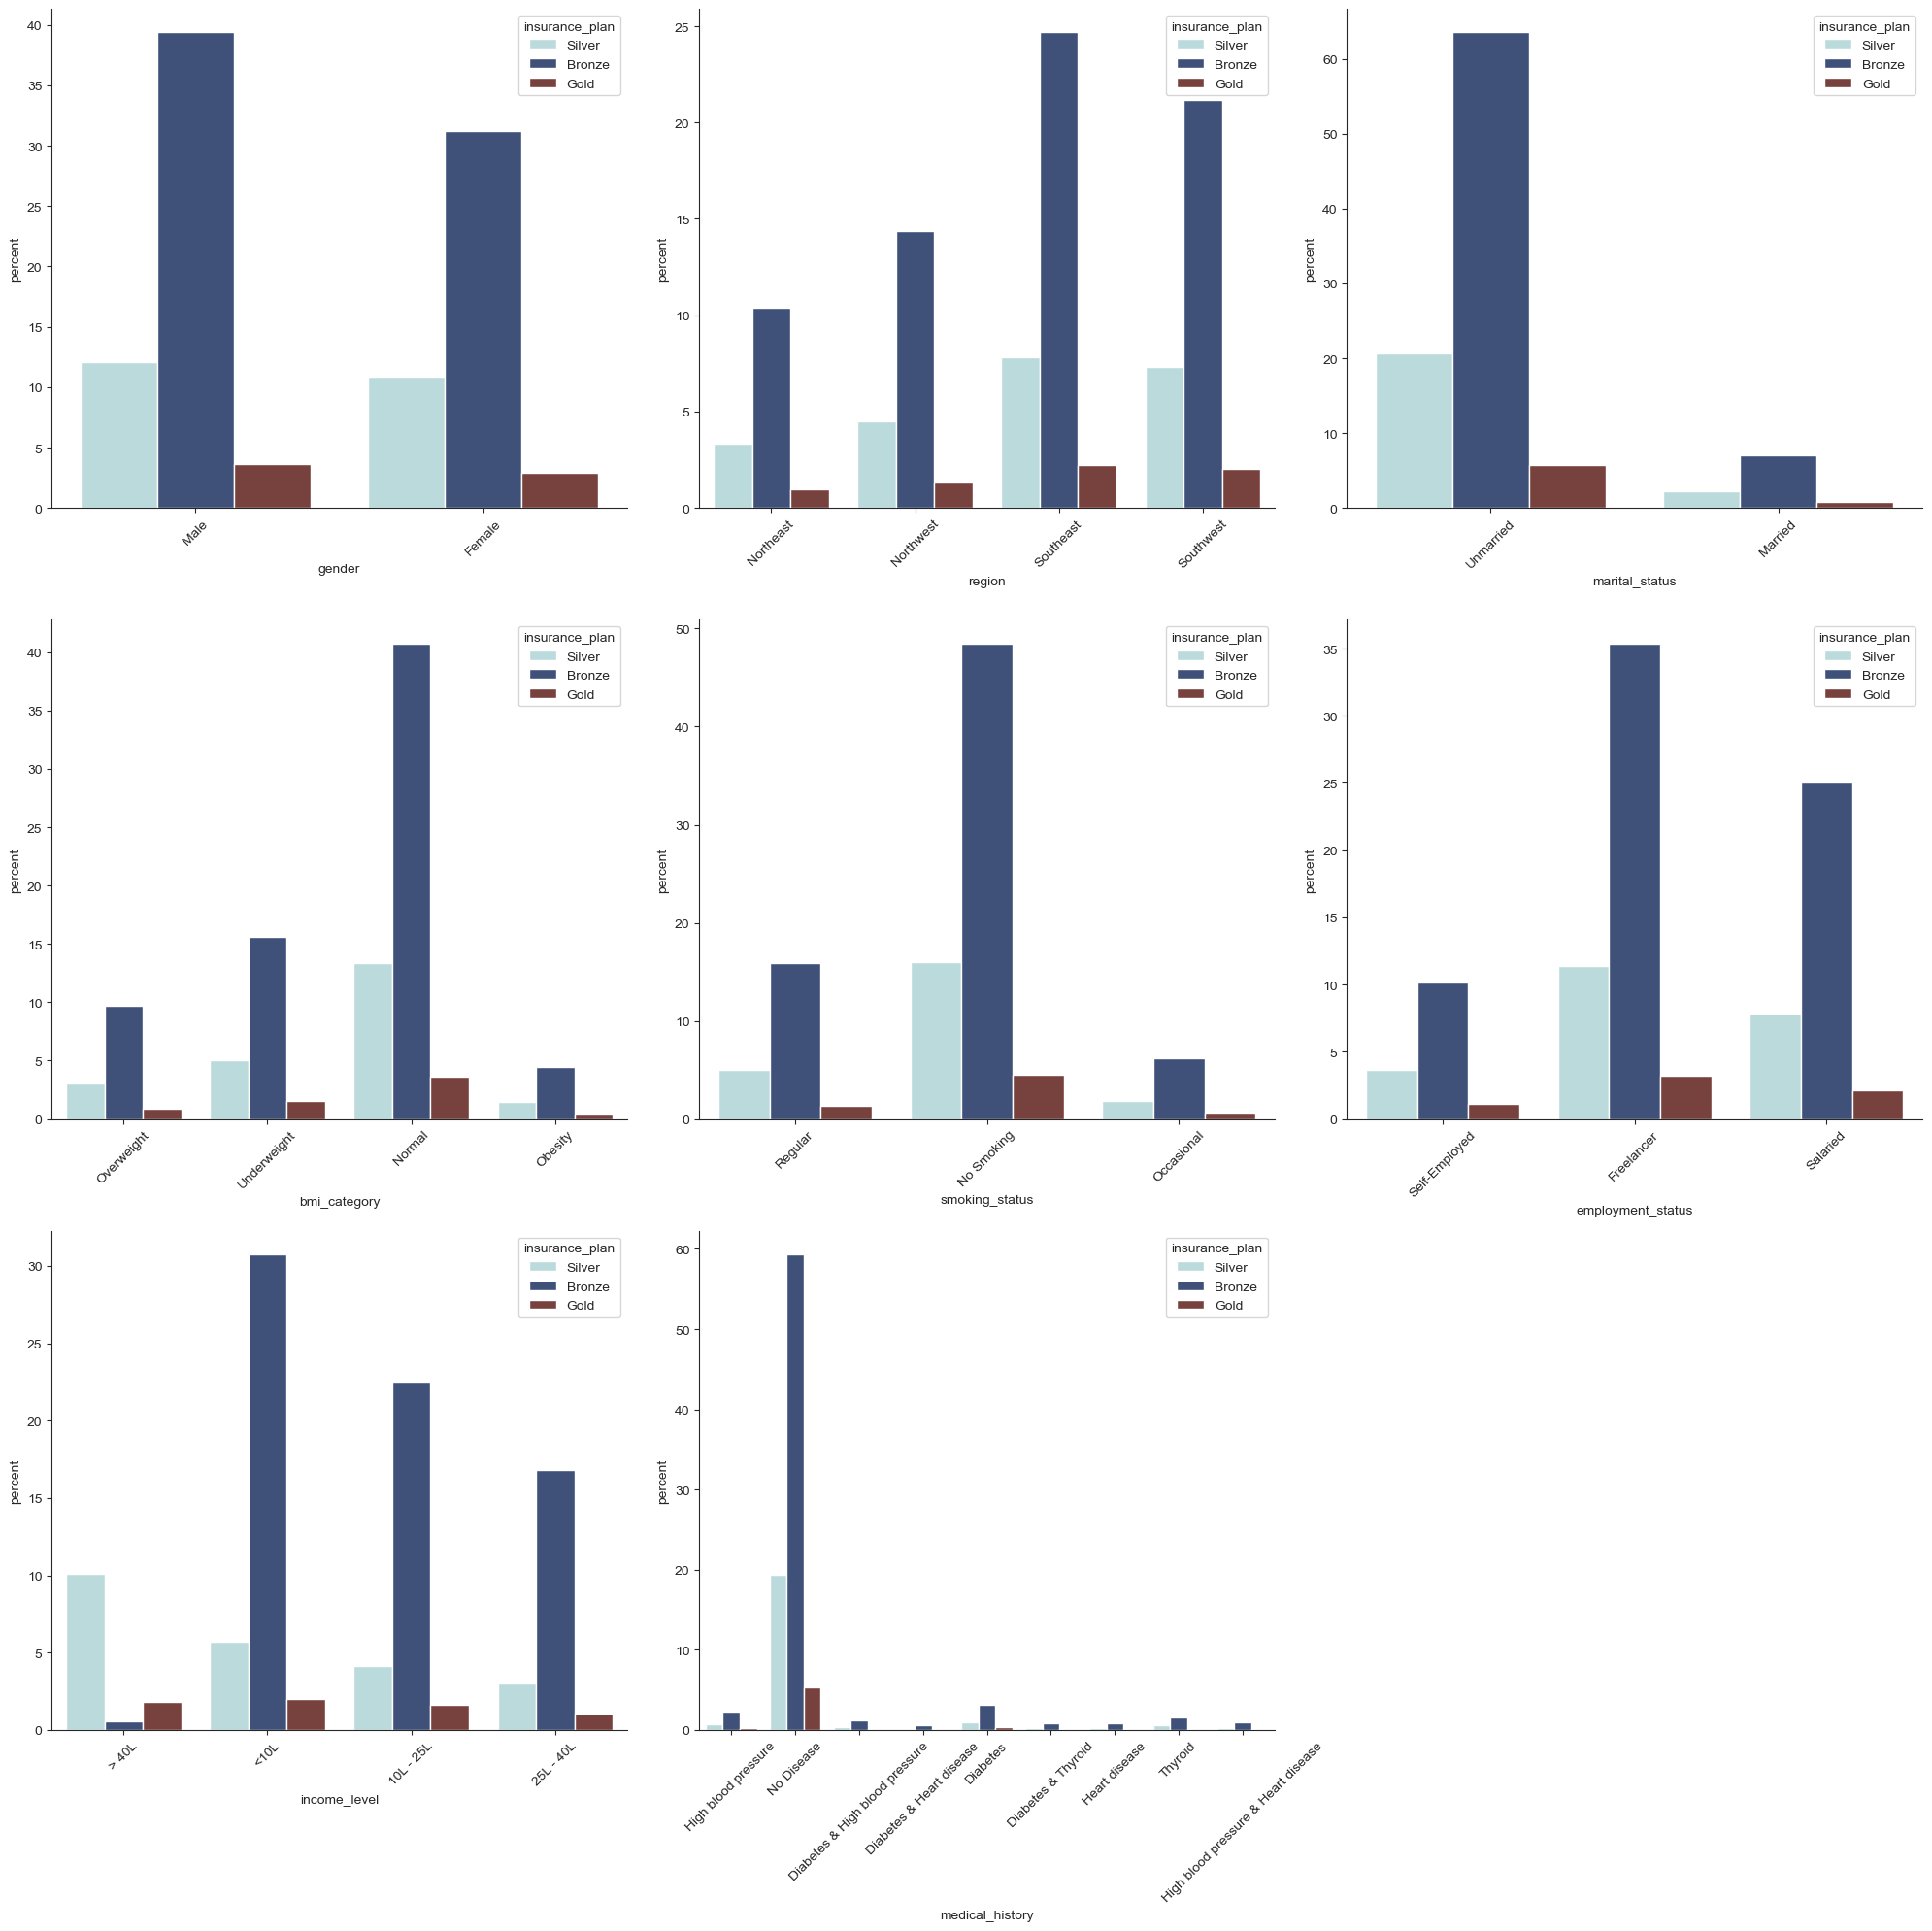

In [123]:
plt.figure(figsize=(20, 20))
sns.set_style('ticks')

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)
Palette = ["#B5DFE2", "#354E83", "#803835"]

for i, col in enumerate(categorical_cols.drop('insurance_plan'), start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent', hue= data['insurance_plan'], palette= Palette)
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


<h3  style = "color: skyblue">Feature Engineering</h3>

1. Feature Construction
2. Feature Transformation
3. Feature Selection

#### 1. Feature Construction

In [124]:
data.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [125]:
data['medical_history'].unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [126]:
# Define the risk scores for each condition

risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [127]:
#sep each diseases, make dataframe, and make each case lower
data[['disease1', 'disease2']] = data['medical_history'].str.split("&", expand= True).apply( lambda x:x.str.lower().str.strip())

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2
17016,21,Female,Southwest,Married,3,Normal,No Smoking,Salaried,10L - 25L,14,No Disease,Bronze,5233,1,no disease,None
13939,19,Female,Northeast,Unmarried,2,Overweight,Regular,Freelancer,<10L,4,No Disease,Bronze,5579,1,no disease,None
4568,18,Male,Southwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,28,No Disease,Bronze,5062,0,no disease,None
4508,22,Female,Southwest,Unmarried,0,Underweight,No Smoking,Salaried,<10L,8,No Disease,Bronze,5307,1,no disease,None
16352,25,Female,Northwest,Unmarried,1,Normal,No Smoking,Freelancer,10L - 25L,16,No Disease,Bronze,7432,3,no disease,None


In [128]:
data['disease1'] = data['disease1'].fillna('none')
data['disease2'] = data['disease1'].fillna('none')

data['total_risk_scores'] = 0

In [129]:
data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_scores
10838,19,Female,Southwest,Married,3,Normal,No Smoking,Salaried,<10L,2,No Disease,Bronze,8388,4,no disease,no disease,0
11046,22,Male,Southeast,Unmarried,1,Obesity,No Smoking,Salaried,10L - 25L,18,No Disease,Bronze,6071,1,no disease,no disease,0
18210,22,Male,Southeast,Unmarried,0,Underweight,No Smoking,Salaried,25L - 40L,25,Diabetes & High blood pressure,Gold,12263,0,diabetes,diabetes,0
10088,19,Male,Southwest,Unmarried,1,Obesity,Regular,Salaried,10L - 25L,20,No Disease,Bronze,7794,2,no disease,no disease,0
18158,18,Male,Southwest,Unmarried,0,Normal,Regular,Salaried,25L - 40L,35,No Disease,Bronze,7376,3,no disease,no disease,0


In [130]:
for disease in ['disease1', 'disease2']:
    data['total_risk_scores'] += data[disease].map(risk_scores)

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_scores
13860,20,Female,Northwest,Unmarried,2,Normal,No Smoking,Self-Employed,<10L,7,No Disease,Gold,11522,1,no disease,no disease,0
11419,18,Male,Northeast,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,28,No Disease,Bronze,4962,0,no disease,no disease,0
15131,23,Male,Southwest,Unmarried,0,Normal,No Smoking,Salaried,25L - 40L,39,No Disease,Bronze,8239,4,no disease,no disease,0
10722,21,Female,Northwest,Unmarried,0,Normal,Occasional,Salaried,> 40L,75,Diabetes & Thyroid,Gold,17227,5,diabetes,diabetes,12
371,19,Male,Southwest,Unmarried,0,Underweight,No Smoking,Freelancer,25L - 40L,35,No Disease,Bronze,7355,3,no disease,no disease,0


#### 2. Feature Transformation

1. Label Encoding : `Ordinal Data`
2. One Hot Encoding: `Nominal Data`
3. Feature Scaling

Label Encoding for Ordinal Data

In [131]:
#For insurnace plan
#can do label encoding since it is ordinal data
data['insurance_plan'] = data['insurance_plan'].map({
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3
})

data['insurance_plan'].unique()

array([2, 1, 3], dtype=int64)

In [132]:
#similarly for income_level we can do Label encoding
data['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [133]:
data['income_level'] = data['income_level'].map({
    '<10L': 1,
    '10L - 25L': 2,
    '25L - 40L': 3,
    '> 40L': 4
})

data['income_level'].unique()

array([4, 1, 2, 3], dtype=int64)

One Hot Encoding for Nominal Data

In [134]:
data.select_dtypes('object').columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'medical_history', 'disease1', 'disease2'],
      dtype='object')

In [135]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

data_v1 = pd.get_dummies(data=data, columns= nominal_cols, drop_first= True, dtype='int')
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,4,high blood pressure,high blood pressure,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,3,no disease,no disease,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,4,no disease,no disease,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,2,no disease,no disease,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,1,no disease,no disease,...,1,0,1,0,1,0,0,0,0,0


Feature Scaling

In [136]:
#Use MinMaxScaler
cols_to_scale = ['age', 'number_of_dependants', 'income_level',	'income_lakhs',	'insurance_plan', 'total_risk_scores', 'genetical_risk']

scaler = MinMaxScaler()
data_v1[cols_to_scale] = scaler.fit_transform(data_v1[cols_to_scale])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,High blood pressure,0.5,13365,0.8,high blood pressure,high blood pressure,...,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,No Disease,0.5,11050,0.6,no disease,no disease,...,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,No Disease,0.5,11857,0.8,no disease,no disease,...,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,No Disease,0.0,5684,0.4,no disease,no disease,...,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,No Disease,0.0,5712,0.2,no disease,no disease,...,1,0,1,0,1,0,0,0,0,0


#### 3. Feature Selection

1. Business understanding

2. Statistical Techniques:
      - Filtered-based : correlation matrix
      - Embedded method

In [137]:
data_v1.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'disease1', 'disease2', 'total_risk_scores',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [138]:
#Dropping some columns that is not necessary
data_v1 = data_v1.drop(columns=['medical_history', 'disease1', 'disease2'])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,13365,0.8,0.75,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,11050,0.6,0.00,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,11857,0.8,0.00,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,5684,0.4,0.00,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,5712,0.2,0.00,1,0,1,0,1,0,1,0,0,0,0,0


#### 1. Filtered-based method

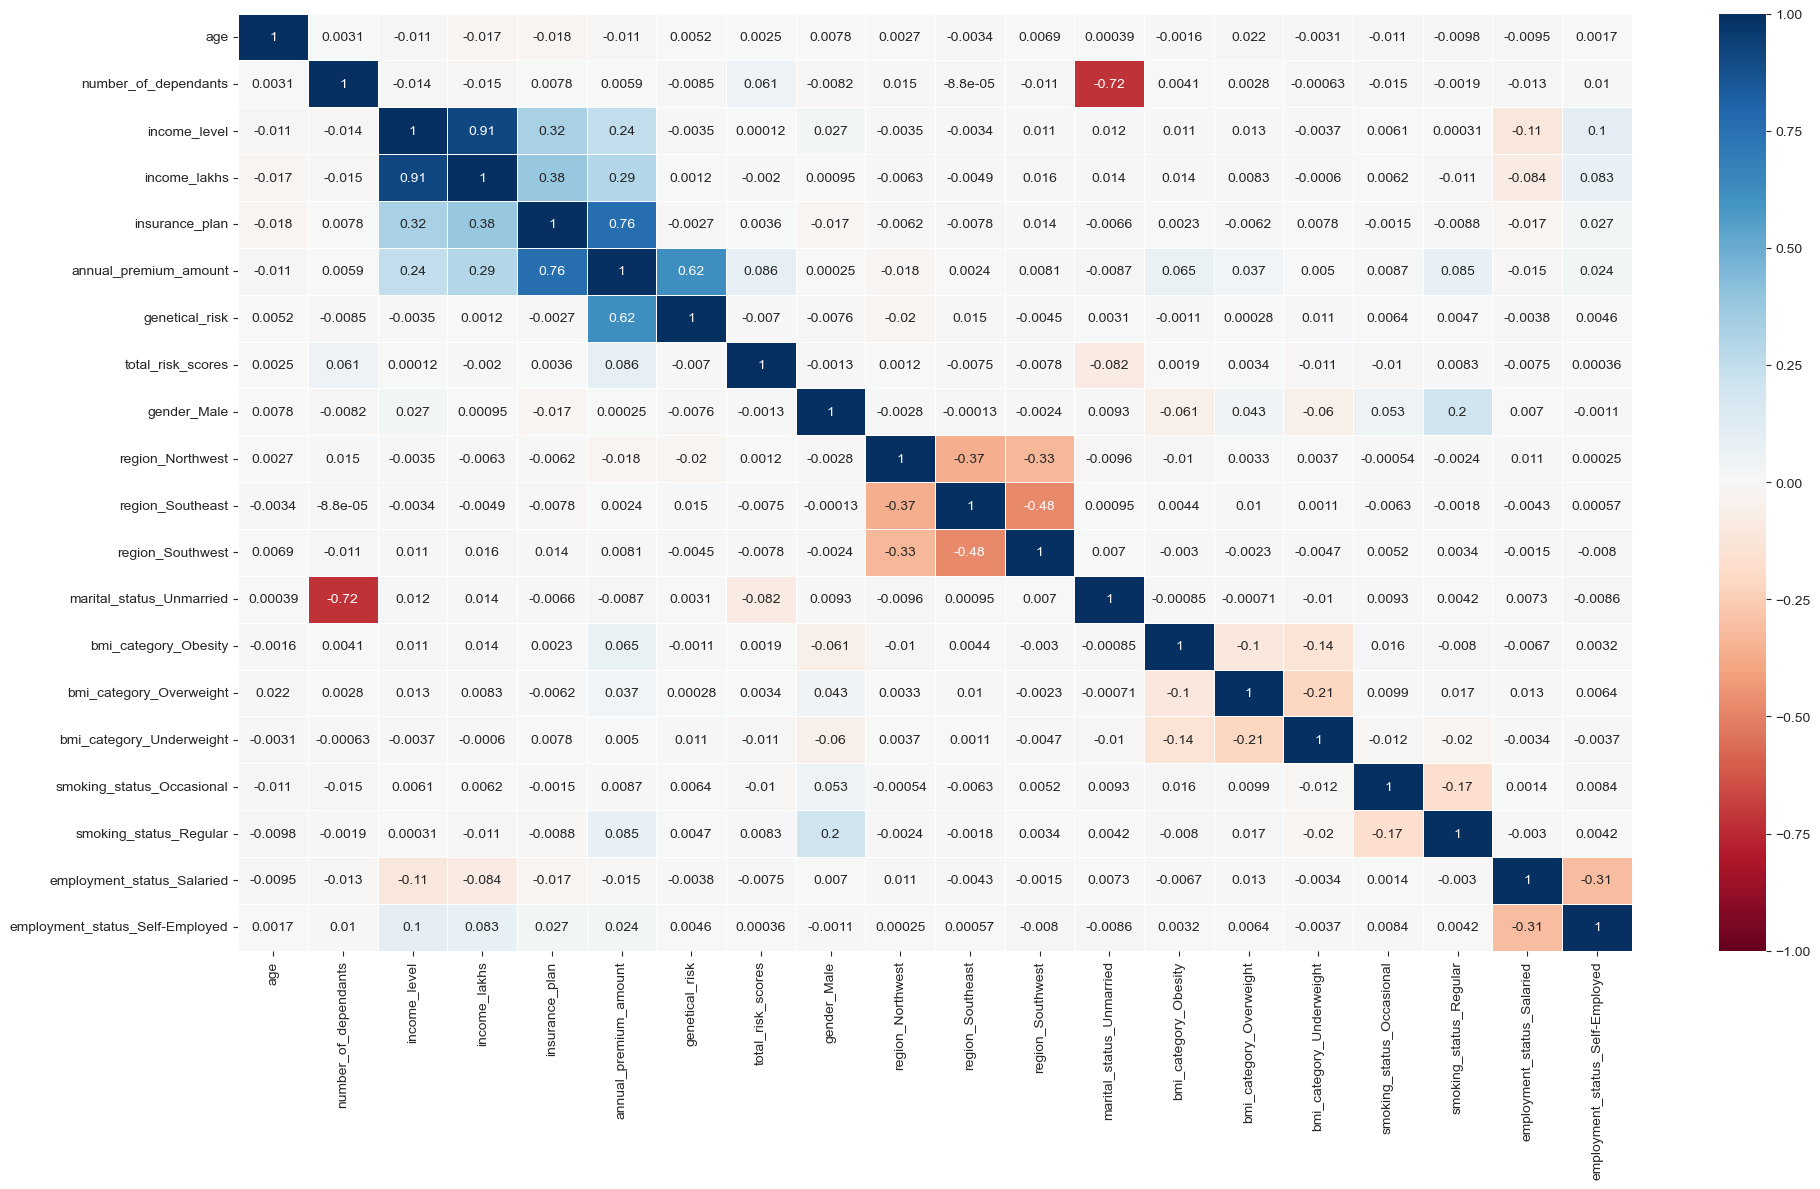

In [139]:
#Correlation matrix
cm = data_v1.corr()

plt.figure(figsize=(20,12))
sns.set_style('ticks')

sns.heatmap(cm, annot= True, vmin= -1, vmax=1, cmap="RdBu", linewidths=0.7)
plt.tight_layout()
plt.show()

Strong multicollinearity: (income_level, income_lakhs) and (insurance_plan, annual_premium_amount) are highly correlated.

Marital status effects: Unmarried is strongly negatively related to age, dependants, and premium.

##### Calculate VIF for Multicolinearity

In [140]:
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,13365,0.8,0.75,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,11050,0.6,0.00,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,11857,0.8,0.00,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,5684,0.4,0.00,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,5712,0.2,0.00,1,0,1,0,1,0,1,0,0,0,0,0


In [141]:
X = data_v1.drop(columns=['annual_premium_amount'])
y = data_v1['annual_premium_amount']

In [142]:
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,0.8,0.75,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,0.6,0.00,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,0.8,0.00,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,0.4,0.00,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,0.2,0.00,1,0,1,0,1,0,1,0,0,0,0,0


In [143]:
y[:5]

0    13365
1    11050
2    11857
3     5684
4     5712
Name: annual_premium_amount, dtype: int64

In [144]:
def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])] 

    return vif_df

In [145]:
calculate_vif(X)

,Columns,VIF
0,age,3.155266
1,number_of_dependants,1.934753
2,income_level,11.929352
3,income_lakhs,11.876405
4,insurance_plan,1.592983
5,genetical_risk,2.981603
6,total_risk_scores,1.181673
7,gender_Male,2.311887
8,region_Northwest,2.154766
9,region_Southeast,2.991028


In [146]:
#we will drop income_lakhs due to high VIF value
X = X.drop(columns=['income_level'])

In [147]:
#recalculating VIF

calculate_vif(X)

,Columns,VIF
0,age,3.153938
1,number_of_dependants,1.932170
2,income_lakhs,2.294423
3,insurance_plan,1.587879
4,genetical_risk,2.981603
5,total_risk_scores,1.181560
6,gender_Male,2.301732
7,region_Northwest,2.153844
8,region_Southeast,2.989848
9,region_Southwest,2.744232


In [148]:
X.shape

(20086, 18)

<h3  style = "color: skyblue" >Modeling<h3>


Hold-out approach

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train:", X_train.shape)
print("y train:", y_train.shape)
print("y train:", X_test.shape)
print("y test:", y_test.shape)

x train: (14060, 18)
y train: (14060,)
y train: (6026, 18)
y test: (6026,)


Base Model: Linear Regression

In [150]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [151]:
y_pred = model_lr.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 94013.02252075326
RMSE: 306.6154309892985
R2 Score: 0.9876374284638847


Cross validation appraoch

In [152]:
kfold = KFold(n_splits=5, shuffle= True, random_state=42)

scores = cross_val_score(estimator = model_lr, X= X, y= y, cv=kfold, scoring='r2')

print("R2 scores for each folds:", scores)
print("Mean R2 score across all folds:", np.mean(scores))

R2 scores for each folds: [0.98694625 0.98758894 0.98751741 0.98690606 0.9875707 ]
Mean R2 score across all folds: 0.9873058715159356


In [153]:
model_lr.intercept_

3962.139486487068

In [154]:
model_lr.coef_

array([-4.75398485e+00,  2.14847998e+01, -1.07505093e+01,  7.00348356e+03,
        4.99659272e+03,  8.62012074e+02,  7.50281664e+00,  2.96619305e+00,
       -3.57227333e+00,  8.28323017e+00,  3.35582749e+01,  8.10745636e+02,
        4.00204122e+02,  1.07004150e+02,  2.04101728e+02,  6.10274174e+02,
       -2.32198357e-03, -5.43629644e+00])

In [155]:
feature_importance = model_lr.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
income_lakhs,-10.750509
employment_status_Self-Employed,-5.436296
age,-4.753985
region_Southeast,-3.572273
employment_status_Salaried,-0.002322
region_Northwest,2.966193
gender_Male,7.502817
region_Southwest,8.283230
number_of_dependants,21.484800
marital_status_Unmarried,33.558275


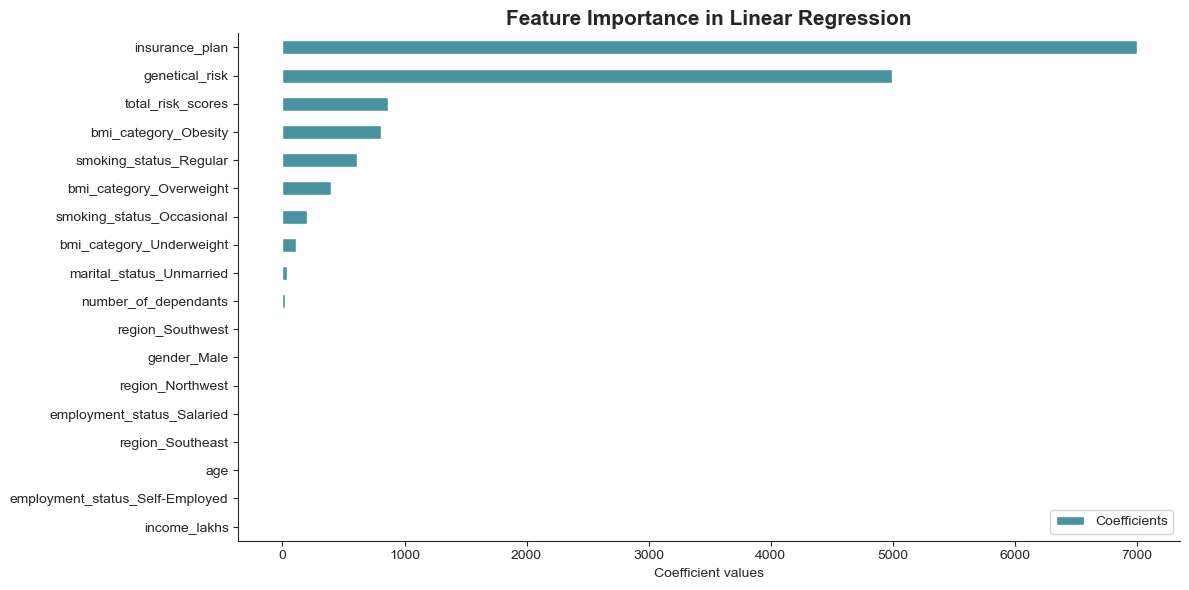

In [156]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Linear Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

Ridge Regression Model

In [157]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)

Ridge()

In [158]:
y_pred = model_rg.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 93996.74635192519
RMSE: 306.58888817425395
R2 Score: 0.9876395687556876


Lasso Regression Model

In [159]:
model_la = Lasso()
model_la.fit(X_train, y_train)

Lasso()

In [160]:
y_pred = model_la.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 93931.86445460904
RMSE: 306.48305736958616
R2 Score: 0.9876481006279269


In [161]:
model_la.intercept_

4007.403169498997

In [162]:
model_la.coef_

array([-0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  6.98904941e+03,
        4.98790349e+03,  8.47869281e+02,  4.11317336e+00,  0.00000000e+00,
       -2.41288911e+00,  3.13543900e+00,  5.44153691e+00,  7.89492002e+02,
        3.87828306e+02,  9.63950100e+01,  1.90251124e+02,  6.03485709e+02,
        0.00000000e+00, -0.00000000e+00])

In [163]:
feature_importance = model_la.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
region_Southeast,-2.412889
employment_status_Salaried,0.000000
region_Northwest,0.000000
age,-0.000000
income_lakhs,-0.000000
number_of_dependants,0.000000
employment_status_Self-Employed,-0.000000
region_Southwest,3.135439
gender_Male,4.113173
marital_status_Unmarried,5.441537


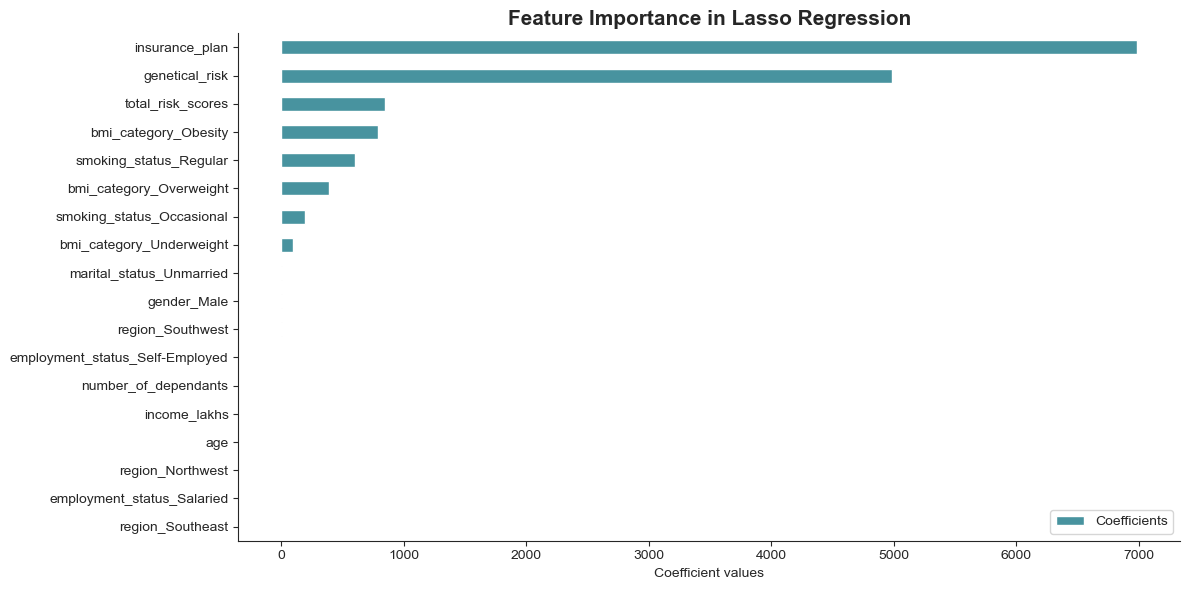

In [164]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Lasso Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

XGBoost : XGBRegressor Model

In [165]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [166]:
y_pred = model_xgb.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 104279.35903615988
RMSE: 322.9231472597774
R2 Score: 0.9862874206013299


#### Hyparameter Tuning: XGBRegressor

1. Randomizedsearch CV

In [167]:
#use randomizedsearch cv
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

rscv = RandomizedSearchCV(estimator= model_xgb, param_distributions= param_grid, n_iter= 10, cv= kfold, scoring='r2')
rscv.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=Non...
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [20, 40, 50]},
                   scoring='r2')

In [168]:
#print the best parameters and best scores
print(f"Best parameters: {rscv.best_params_}")
print(f"Best Score: {rscv.best_score_}")

#best model according to randomsearch cv
best_model = rscv.best_estimator_

Best parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.2}
Best Score: 0.9870664727573495


#### Model Selection

In [169]:
best_model = model_lr

In [170]:
feature_importance = model_lr.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
income_lakhs,-10.750509
employment_status_Self-Employed,-5.436296
age,-4.753985
region_Southeast,-3.572273
employment_status_Salaried,-0.002322
region_Northwest,2.966193
gender_Male,7.502817
region_Southwest,8.283230
number_of_dependants,21.484800
marital_status_Unmarried,33.558275


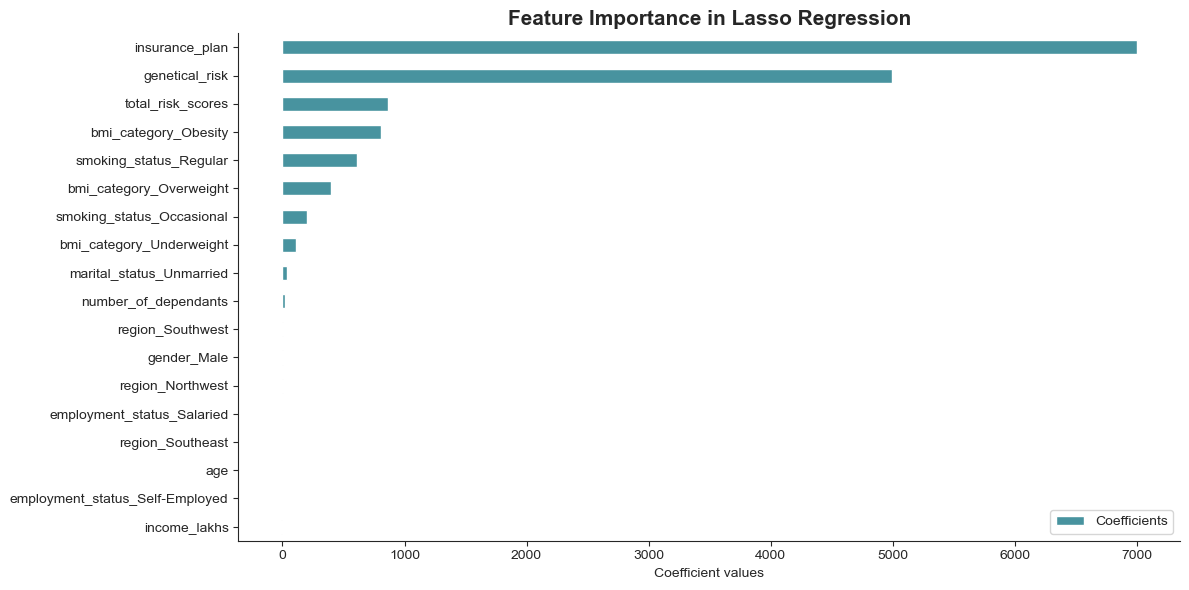

In [171]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Lasso Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

##### R2 metric is not good enough to evaluate the model

#### ERROR ANALYSIS

In [172]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals * 100) / y_test

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})

results_df

,actual,predicted,diff,diff_pct
12774,6238,6126.259896,-111.740104,-1.791281
14758,9462,9603.401758,141.401758,1.494417
13205,5152,5612.568814,460.568814,8.939612
14278,6988,7420.662096,432.662096,6.191501
19351,4917,5114.004029,197.004029,4.006590
...,...,...,...,...
17652,7635,7994.063772,359.063772,4.702865
5807,4845,4619.093337,-225.906663,-4.662676
10298,13866,13507.244272,-358.755728,-2.587305
13316,5255,5109.523271,-145.476729,-2.768349


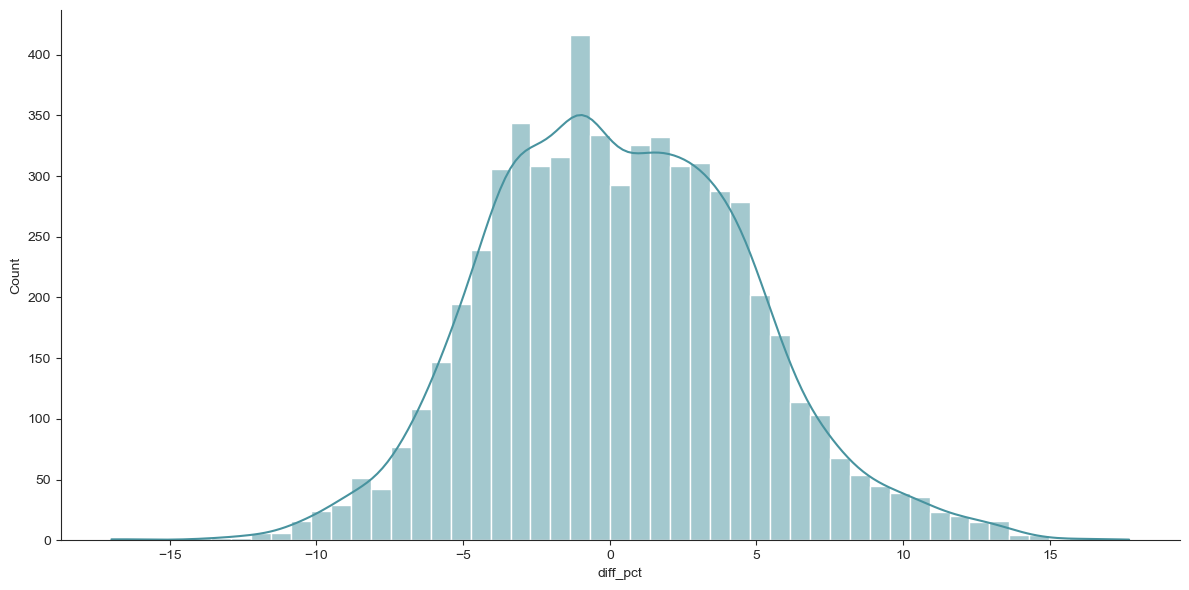

In [173]:
plt.figure(figsize=(12,6))
sns.histplot(results_df['diff_pct'], kde= True, color="#48939F")
sns.despine()
plt.tight_layout()
plt.show()

The distribution of diff_pct is sharply centered around 0%, indicating most predictions are close to the actual values, but it is right-skewed with a long positive tail, showing the model occasionally makes large over-predictions (and fewer extreme under-predictions).

In [174]:
# This dataframe isolates the predictions that are unacceptably inaccurate, based on a 10% error tolerance.
extreme_error_threshold = 10

extreme_result_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_result_df

,actual,predicted,diff,diff_pct
12669,3985,4395.755261,410.755261,10.307535
2918,4517,5002.495846,485.495846,10.748192
209,8392,7468.237120,-923.762880,-11.007661
17084,3562,3994.645908,432.645908,12.146151
13565,4671,4202.656378,-468.343622,-10.026624
...,...,...,...,...
17220,9619,8649.608783,-969.391217,-10.077879
8008,4902,5401.724971,499.724971,10.194308
9714,3624,3999.152794,375.152794,10.351898
10997,5054,5652.420702,598.420702,11.840536


In [175]:
extreme_error_pct = extreme_result_df.shape[0] * 100 / results_df.shape[0]
extreme_error_pct

2.970461334218387

We have very few extreme errors (only 3%) which means this model looks good and no further investigation is required

In [176]:
results_df[np.abs(results_df['diff_pct']) > 50].sort_values(by='diff_pct', ascending= False)

,actual,predicted,diff,diff_pct


<p>There are zero customers that are expected to be overcharged or undercharged by more than 50%</p>

<h3 style = "color:skyblue" >Export The Model</h3>

In [182]:
from joblib import dump

dump(best_model, "../artifacts/model_young.joblib")

scaler_with_cols = {
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}

dump(scaler_with_cols, "../artifacts/scaler_young.joblib")

['../artifacts/scaler_young.joblib']